In [3]:
from statsbombpy import sb
comps = sb.competitions()
comps.head()

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [7]:
from statsbombpy import sb
matches = sb.matches(competition_id=9, season_id=281)
matches[['match_id','home_team','away_team']].head()

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,home_team,away_team
0,3895292,Union Berlin,Bayer Leverkusen
1,3895320,Bayer Leverkusen,VfB Stuttgart
2,3895158,Bayer Leverkusen,Borussia Dortmund
3,3895107,Bayer Leverkusen,FC Köln
4,3895340,Bochum,Bayer Leverkusen


In [27]:
from statsbombpy import sb
events = sb.events(3895158)
shots = events[events['type'] == 'Shot']
shots[['player', 'team', 'type',  'shot_type', 'shot_outcome', 'location']].head(100)

C:\Users\pryde\Documents\Football\Analysis\football-analytics\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,player,team,type,shot_type,shot_outcome,location
3633,Julian Ryerson,Borussia Dortmund,Shot,Open Play,Goal,"[111.3, 33.9]"
3634,Exequiel Alejandro Palacios,Bayer Leverkusen,Shot,Open Play,Saved,"[99.6, 38.1]"
3635,Granit Xhaka,Bayer Leverkusen,Shot,Open Play,Saved,"[95.5, 52.8]"
3636,Jonas Hofmann,Bayer Leverkusen,Shot,Open Play,Off T,"[98.6, 34.3]"
3637,Granit Xhaka,Bayer Leverkusen,Shot,Open Play,Off T,"[95.8, 48.2]"
3638,Jonathan Tah,Bayer Leverkusen,Shot,Open Play,Wayward,"[114.7, 48.5]"
3639,Alejandro Grimaldo García,Bayer Leverkusen,Shot,Free Kick,Saved,"[92.9, 33.0]"
3640,Jamie Jermaine Bynoe-Gittens,Borussia Dortmund,Shot,Open Play,Blocked,"[103.4, 34.6]"
3641,Victor Okoh Boniface,Bayer Leverkusen,Shot,Open Play,Off T,"[108.3, 44.3]"
3642,Exequiel Alejandro Palacios,Bayer Leverkusen,Shot,Open Play,Off T,"[94.0, 36.0]"


In [32]:
import numpy as np
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])
shots['distance_to_goal_yards'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2)
shots['distance_to_goal'] = shots['distance_to_goal_yards'] * 0.9144
shots['is_goal'] = (shots['shot_outcome'] == 'Goal').astype(int)
shots[['player', 'distance_to_goal', 'is_goal']]

,player,distance_to_goal,is_goal
3633,Julian Ryerson,9.715903,1
3634,Exequiel Alejandro Palacios,18.734492,0
3635,Granit Xhaka,25.276007,0
3636,Jonas Hofmann,20.250399,0
3637,Granit Xhaka,23.364307,0
3638,Jonathan Tah,9.159532,0
3639,Alejandro Grimaldo García,25.593564,0
3640,Jamie Jermaine Bynoe-Gittens,15.961978,0
3641,Victor Okoh Boniface,11.398134,0
3642,Exequiel Alejandro Palacios,24.054108,0


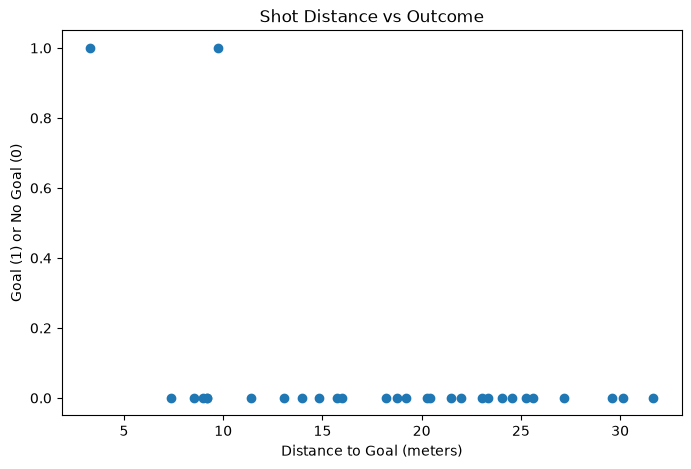

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(shots['distance_to_goal'], shots['is_goal'])
plt.xlabel('Distance to Goal (meters)')
plt.ylabel('Goal (1) or No Goal (0)')
plt.title('Shot Distance vs Outcome')
plt.show()

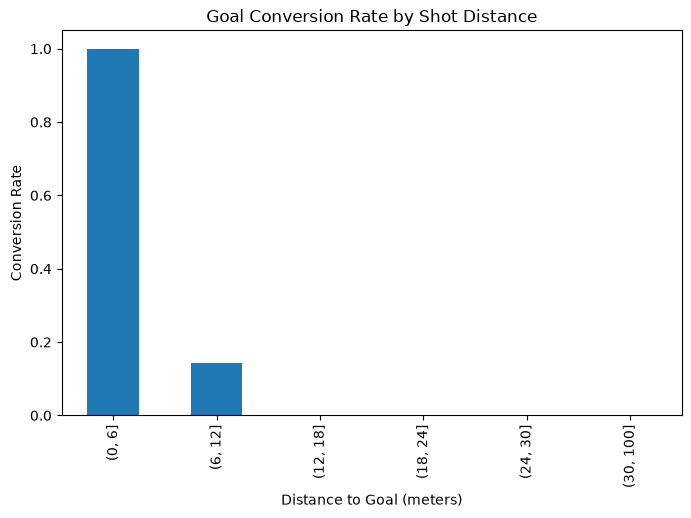

In [34]:
import pandas as pd

shots['distance_bin'] = pd.cut(shots['distance_to_goal'], bins=[0,6,12,18,24,30,100])
conversion_by_bin = shots.groupby('distance_bin')['is_goal'].mean()

conversion_by_bin.plot(kind='bar', figsize=(8,5))
plt.ylabel('Conversion Rate')
plt.xlabel('Distance to Goal (meters)')
plt.title('Goal Conversion Rate by Shot Distance')
plt.show()

In [35]:
correlation = shots['distance_to_goal'].corr(shots['is_goal'])
print(correlation)

-0.41960763220648106
